### [Quantitative Finance: Portfolio Optimization](https://medium.com/financial-engineering/quantitative-finance-series-portfolio-optimization-with-python-47cf6da850aa)

#### **Modern Portfolio Theory (MPT)**
MPT says that by combining assets that don't move perfectly in sync, the overall risk can be reduced without sacrificing returns.

MPT is built on a few key statistical concepts:

- **Expected Return**: The expected return of a portfolio is the weighted average of the expected returns of the individual assets.
- **Portfolio Volatility (Risk)**: This is where it gets interesting. The risk of a portfolio is not just the weighted average of the individual asset risks. It also depends on how the assets move with respect to each other. This relationship is measured by covariance. If two assets move in opposite directions (-ve covariance), combining them can lower the portfolio’s volatility.
- **The Efficient Frontier**: Imagine plotting every possible combination of assets on a chart of risk vs. return. The Efficient Frontier is a curve representing the set of "best" portfolios. For a given level of risk, no portfolio offers a higher return than the one on the Efficient Frontier. Conversely, for any given level of return, there is no portfolio with lower risk.
- **The Sharpe Ratio**: So how do we choose the single "best" portfolio from all the options on the Efficient Frontier? We use the Sharpe Ratio. It measures the portfolio's return in excess of the risk-free rate, per unit of risk. The portfolio on the Efficient Frontier with the highest Sharpe Ratio is considered the "optimal" risky portfolio.

$Sharpe Ratio = (Portfolio Return — Risk-Free Rate) / Portfolio Volatility$

In [1]:
!pip install -q numpy pandas yfinance matplotlib scipy

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

# Define the list of tickers for our portfolio
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM', 'V', 'PG', 'JNJ']

# Define the time period for our historical data
start_date = datetime(2018, 1, 1)
end_date = datetime(2024, 12, 31)

# Fetch the 'Adj Close' prices using yfinance
adj_close_df = pd.DataFrame()
for ticker in tickers:
    # Use yf.download to fetch data
    data = yf.download(ticker, start=start_date, end=end_date)
    adj_close_df[ticker] = data['Close']

print("Last 5 days of historical data:")
print(adj_close_df.tail())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Last 5 days of historical data:
                  AAPL        MSFT       GOOGL        AMZN         JPM  \
Date                                                                     
2024-12-23  254.120682  432.871429  193.997543  225.059998  233.448135   
2024-12-24  257.037476  436.929138  195.472733  229.050003  237.286880   
2024-12-26  257.853760  435.715790  194.964386  227.050003  238.099670   
2024-12-27  254.439209  428.177216  192.133591  223.750000  236.170502   
2024-12-30  251.064484  422.508331  190.618546  221.300003  234.358871   

                     V          PG         JNJ  
Date                                            
2024-12-23  314.982788  163.782837  141.850220  
2024-12-24  318.388611  164.591461  142.416565  
2024-12-26  318.646820  165.780090  142.152908  
2024-12-27  316.412659  165.166290  141.635391  
2024-12-30  313.086273  162.789093  139.965652  


##### Calculate Returns and Covariance

In [3]:
# Calculate daily log returns
log_returns = np.log(adj_close_df / adj_close_df.shift(1))

# Remove the first row of NaN values
log_returns = log_returns.dropna()

# Calculate the mean of daily log returns (our expected returns)
mean_log_returns = log_returns.mean()

# Calculate the covariance of daily log returns
cov_matrix = log_returns.cov()

print("\nAnnualized Expected Returns:")
print(mean_log_returns * 252) # 252 trading days in a year


Annualized Expected Returns:
AAPL     0.261931
MSFT     0.239859
GOOGL    0.182585
AMZN     0.188302
JPM      0.142411
V        0.152038
PG       0.114227
JNJ      0.031856
dtype: float64


##### Simulate Thousands of Random Portfolios

In [4]:
# Set up our simulation parameters
num_portfolios = 25000
risk_free_rate = 0.02 # A placeholder for the risk-free rate (e.g., a 10-year US Treasury)

# Set up arrays to store our results
portfolio_returns = []
portfolio_volatility = []
portfolio_weights = []
sharpe_ratios = []

# Loop to generate random portfolios
for _ in range(num_portfolios):
    # Generate random weights
    weights = np.random.random(len(tickers))
    # Normalize weights so they sum to 1
    weights /= np.sum(weights)

    # Calculate portfolio return
    # We multiply by 252 to annualize it
    returns = np.sum(mean_log_returns * weights) * 252

    # Calculate portfolio volatility (risk)
    # We multiply by sqrt(252) to annualize it
    volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)

    # Calculate Sharpe Ratio
    sharpe = (returns - risk_free_rate) / volatility

    # Store the results
    portfolio_returns.append(returns)
    portfolio_volatility.append(volatility)
    sharpe_ratios.append(sharpe)
    portfolio_weights.append(weights)

# Convert lists to a DataFrame for easier analysis
portfolio_data = { 'Return': portfolio_returns, 'Volatility': portfolio_volatility, 'Sharpe Ratio': sharpe_ratios }

for i, ticker in enumerate(tickers):
    portfolio_data[f'Weight_{ticker}'] = [w[i] for w in portfolio_weights]

portfolios_df = pd.DataFrame(portfolio_data)
portfolios_df

,Return,Volatility,Sharpe Ratio,Weight_AAPL,Weight_MSFT,Weight_GOOGL,Weight_AMZN,Weight_JPM,Weight_V,Weight_PG,Weight_JNJ
0,0.183770,0.221382,0.739760,0.109731,0.195619,0.202891,0.099603,0.084129,0.140848,0.164933,0.002246
1,0.162319,0.205437,0.692764,0.075784,0.129920,0.115496,0.124483,0.162612,0.160434,0.143997,0.087273
2,0.161607,0.205453,0.689241,0.060726,0.179820,0.146483,0.100143,0.081988,0.169927,0.135285,0.125629
3,0.150886,0.195648,0.668985,0.263204,0.000225,0.105229,0.022446,0.012263,0.213660,0.145925,0.237049
4,0.183102,0.224370,0.726932,0.285075,0.019081,0.159333,0.103535,0.180023,0.141111,0.056006,0.055836
...,...,...,...,...,...,...,...,...,...,...,...
24995,0.126854,0.179721,0.594553,0.016999,0.034385,0.049057,0.091356,0.059503,0.255242,0.303434,0.190024
24996,0.190275,0.237049,0.718309,0.193791,0.154103,0.138772,0.195938,0.057572,0.191691,0.009772,0.058361
24997,0.177987,0.213896,0.738617,0.148239,0.163711,0.140744,0.151571,0.117161,0.051655,0.168569,0.058349
24998,0.179529,0.216998,0.735163,0.164641,0.152915,0.103973,0.132295,0.154555,0.130164,0.107895,0.053562


##### Visualize the Efficient Frontier

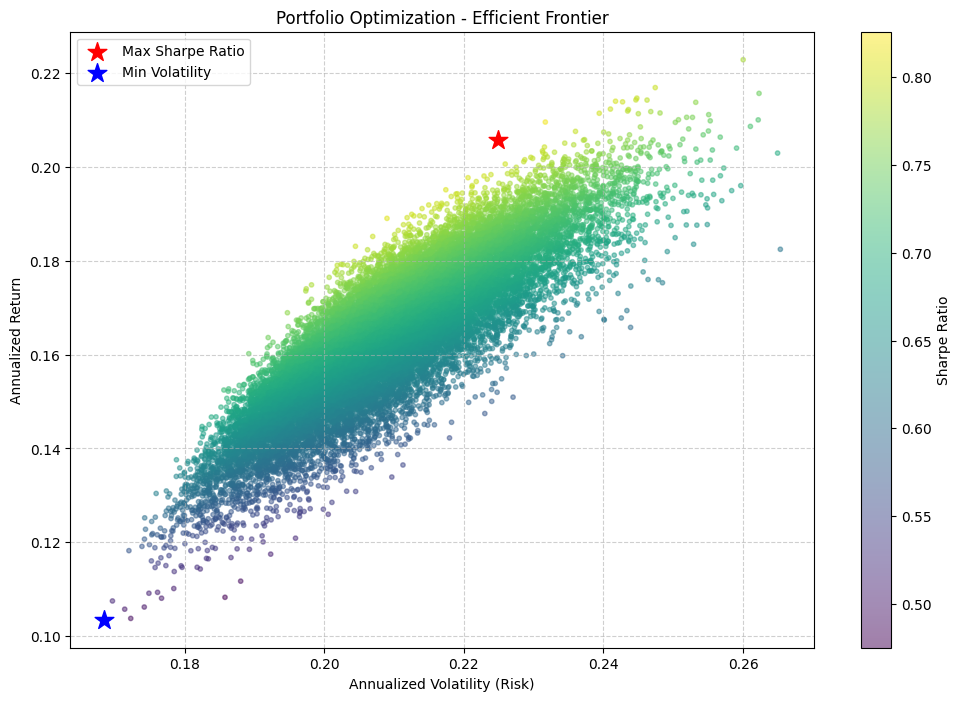

In [5]:
# Find the portfolios with the maximum Sharpe ratio and minimum volatility
max_sharpe_portfolio = portfolios_df.loc[portfolios_df['Sharpe Ratio'].idxmax()]
min_vol_portfolio = portfolios_df.loc[portfolios_df['Volatility'].idxmin()]

# Plot the Efficient Frontier
plt.figure(figsize=(12, 8))
plt.scatter(portfolios_df['Volatility'], portfolios_df['Return'], c=portfolios_df['Sharpe Ratio'], cmap='viridis', marker='o', s=10, alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.title('Portfolio Optimization - Efficient Frontier')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Return')

# Highlight the two key portfolios
plt.scatter(max_sharpe_portfolio['Volatility'], max_sharpe_portfolio['Return'], marker='*', color='r', s=200, label='Max Sharpe Ratio')
plt.scatter(min_vol_portfolio['Volatility'], min_vol_portfolio['Return'], marker='*', color='b', s=200, label='Min Volatility')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##### Analyze the Optimal Portfolios

In [6]:
print("--- Maximum Sharpe Ratio Portfolio ---")
print(f"Annualized Return: {max_sharpe_portfolio['Return']:.2%}")
print(f"Annualized Volatility: {max_sharpe_portfolio['Volatility']:.2%}")
print(f"Sharpe Ratio: {max_sharpe_portfolio['Sharpe Ratio']:.2f}")
print("\nOptimal Weights:")
print(max_sharpe_portfolio.filter(like='Weight').to_string())

print("\n--- Minimum Volatility Portfolio ---")
print(f"Annualized Return: {min_vol_portfolio['Return']:.2%}")
print(f"Annualized Volatility: {min_vol_portfolio['Volatility']:.2%}")
print(f"Sharpe Ratio: {min_vol_portfolio['Sharpe Ratio']:.2f}")
print("\nOptimal Weights:")
print(min_vol_portfolio.filter(like='Weight').to_string())

--- Maximum Sharpe Ratio Portfolio ---
Annualized Return: 20.58%
Annualized Volatility: 22.49%
Sharpe Ratio: 0.83

Optimal Weights:
Weight_AAPL     0.344145
Weight_MSFT     0.257820
Weight_GOOGL    0.028850
Weight_AMZN     0.040132
Weight_JPM      0.111382
Weight_V        0.012929
Weight_PG       0.201714
Weight_JNJ      0.003027

--- Minimum Volatility Portfolio ---
Annualized Return: 10.35%
Annualized Volatility: 16.85%
Sharpe Ratio: 0.50

Optimal Weights:
Weight_AAPL     0.002211
Weight_MSFT     0.023045
Weight_GOOGL    0.056420
Weight_AMZN     0.069654
Weight_JPM      0.037068
Weight_V        0.096007
Weight_PG       0.379859
Weight_JNJ      0.335736


In [7]:
from scipy.optimize import minimize

def get_portfolio_stats(weights):
    returns = np.sum(mean_log_returns * weights) * 252
    volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)
    return np.array([returns, volatility, (returns - risk_free_rate) / volatility])

# Objective function to minimize (we minimize the NEGATIVE Sharpe Ratio)
def minimize_negative_sharpe(weights):
    return -get_portfolio_stats(weights)[2]

# Constraints and bounds
constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})
bounds = tuple((0, 1) for _ in range(len(tickers)))
initial_weights = np.array([1./len(tickers)]*len(tickers))

# Run the optimizer
optimal_sharpe = minimize(minimize_negative_sharpe, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)

print("\n--- SciPy Optimized Max Sharpe Portfolio ---")
optimal_weights = optimal_sharpe.x
stats = get_portfolio_stats(optimal_weights)

print(f"Annualized Return: {stats[0]:.2%}")
print(f"Annualized Volatility: {stats[1]:.2%}")
print(f"Sharpe Ratio: {stats[2]:.2f}")
print("\nOptimal Weights:")

for i, ticker in enumerate(tickers):
    print(f"{ticker}: {optimal_weights[i]:.2%}")


--- SciPy Optimized Max Sharpe Portfolio ---
Annualized Return: 22.42%
Annualized Volatility: 24.17%
Sharpe Ratio: 0.84

Optimal Weights:
AAPL: 45.13%
MSFT: 34.30%
GOOGL: 0.00%
AMZN: 0.00%
JPM: 0.78%
V: 0.00%
PG: 19.79%
JNJ: 0.00%
